## Практика 2. Полная предобработка и EDA датасета. 

### Not fully ready yet!

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

### Загрузка данных и первичный осмотр

In [15]:
titanic_data = pd.read_csv("Titanic-Dataset.csv",  index_col="PassengerId")

titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [17]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [18]:
titanic_data.dtypes

Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Cabin        object
Embarked     object
dtype: object

### Выводы по структуре датасета:

Датасет содержит 891 запись и 11 переменных. 

**Целевая переменная - `Survived`.**
- Она отображает выжил определенный пассажир (значение 1) или же нет (значение 0). Среднее значение `0.384` показывает, что выжило только 38.4% пассажиров. 

**В датасете присутствуют, как числовые, так и категориальные переменные.**
- Числовые: `Age`, `Fare`, `SibSp`, `Parch`.
- Категориальные: `Sex`, `Embarked`, `Cabin`, `Ticket`, `Name`. `Pclass` и `Survived` также являются категориальными переменными, но отображены они численно.

**Есть пропущенные значения**
- В колонке `Age` отсутствует 177 значений - 19.86%
- В колонке `Cabin` отсутствует 687 значений - 77.1%
- В колонке `Embarked` отсутствует 2 значения - 0.22%

**Возраст пассажиров сильно варьируется**
- Минимальный возраст - `0.42`, максимальный - `80`. Средний возраст около 29 лет. 


### EDA

**Распределения**

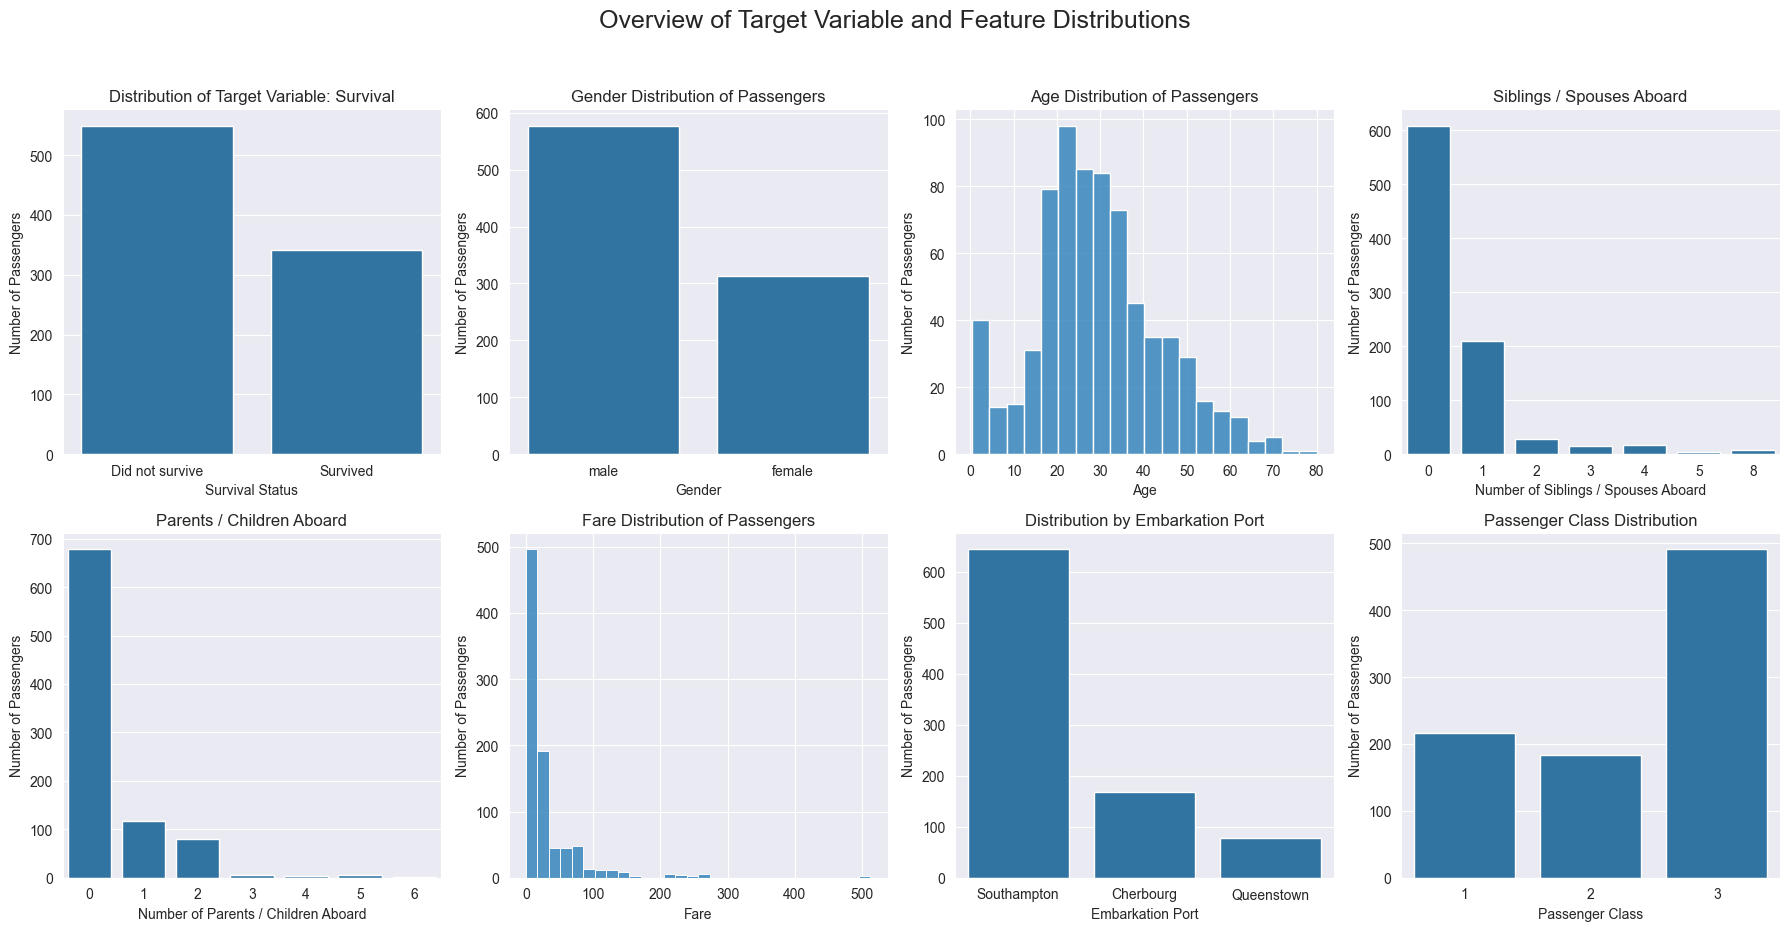

In [19]:
sns.set_style("darkgrid")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

target_df = titanic_data.copy()

target_df["SurvivedLabel"] = target_df["Survived"].map({
    0: "Did not survive",
    1: "Survived"
})

# Target
sns.countplot(data=target_df, x="SurvivedLabel", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Target Variable: Survival")
axes[0, 0].set_xlabel("Survival Status")
axes[0, 0].set_ylabel("Number of Passengers")

# Gender
sns.countplot(data=titanic_data, x="Sex", ax=axes[0, 1])
axes[0, 1].set_title("Gender Distribution of Passengers")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Number of Passengers")

# Age
sns.histplot(data=titanic_data, x="Age", stat="count", ax=axes[0, 2])
axes[0, 2].set_title("Age Distribution of Passengers")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Number of Passengers")

# SibSp
sns.countplot(data=titanic_data, x="SibSp", ax=axes[0, 3])
axes[0, 3].set_title("Siblings / Spouses Aboard")
axes[0, 3].set_xlabel("Number of Siblings / Spouses Aboard")
axes[0, 3].set_ylabel("Number of Passengers")

#Parch
sns.countplot(data=titanic_data, x="Parch", ax=axes[1, 0])
axes[1, 0].set_title("Parents / Children Aboard")
axes[1, 0].set_xlabel("Number of Parents / Children Aboard")
axes[1, 0].set_ylabel("Number of Passengers")

# Fare
sns.histplot(data=titanic_data, x="Fare", bins=30, ax=axes[1, 1])
axes[1, 1].set_title("Fare Distribution of Passengers")
axes[1, 1].set_xlabel("Fare")
axes[1, 1].set_ylabel("Number of Passengers")

#Embark
embark_df = titanic_data.copy()

embark_df["EmbarkPort"] = embark_df["Embarked"].map({
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown"
})

sns.countplot(data=embark_df, x="EmbarkPort", ax=axes[1, 2])
axes[1, 2].set_title("Distribution by Embarkation Port")
axes[1, 2].set_xlabel("Embarkation Port")
axes[1, 2].set_ylabel("Number of Passengers")

#Pclass
sns.countplot(data=titanic_data, x="Pclass", ax=axes[1, 3])
axes[1, 3].set_title("Passenger Class Distribution")
axes[1, 3].set_xlabel("Passenger Class")
axes[1, 3].set_ylabel("Number of Passengers")

fig.suptitle("Overview of Target Variable and Feature Distributions", fontsize=18, y=1.03)


plt.tight_layout()
plt.show()

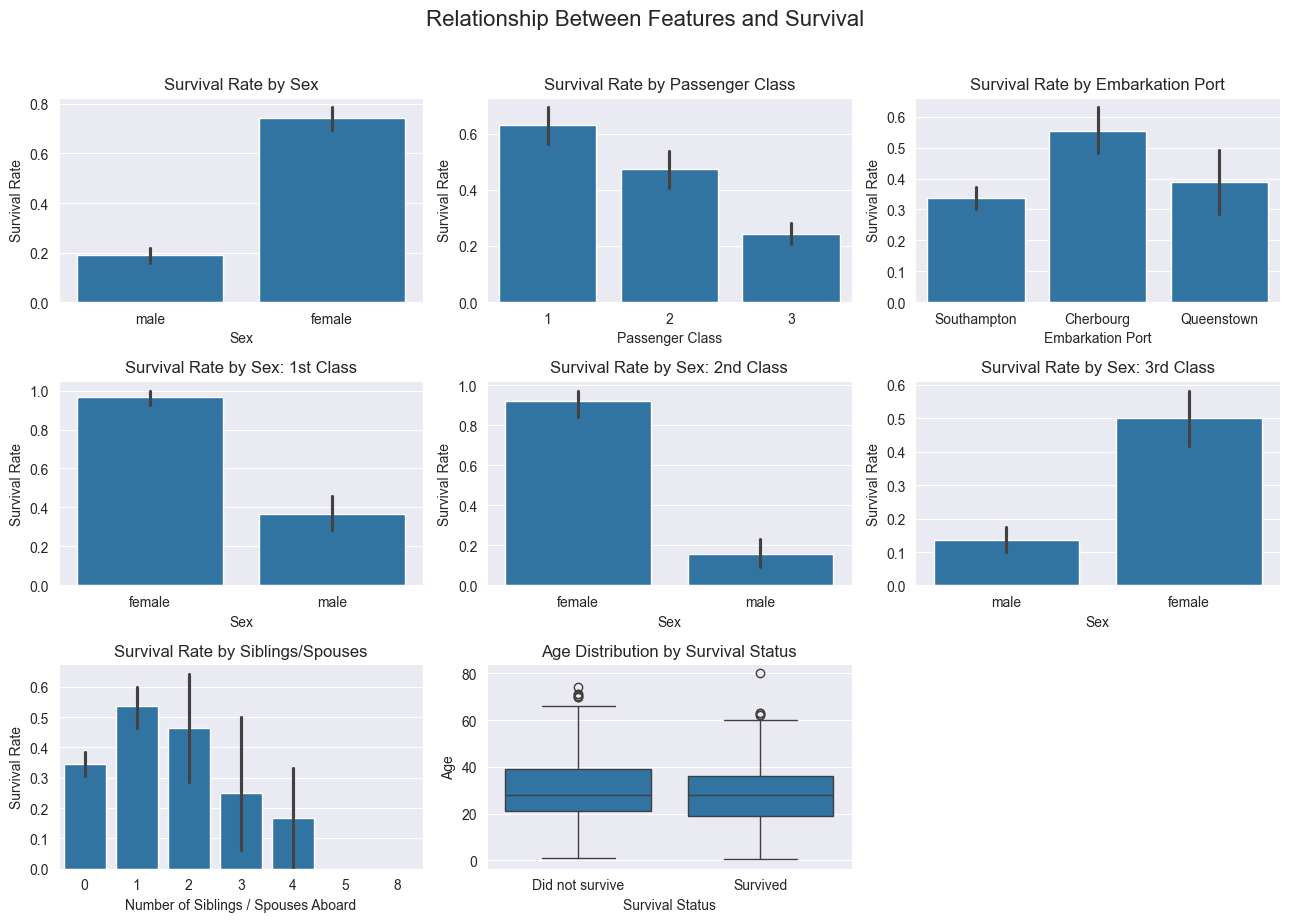

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))

# Sex
sns.barplot(data=titanic_data, x="Sex", y="Survived", ax=axes[0, 0])
axes[0, 0].set_title("Survival Rate by Sex")
axes[0, 0].set_xlabel("Sex")
axes[0, 0].set_ylabel("Survival Rate")


# 2. Pclass
sns.barplot(data=titanic_data, x="Pclass", y="Survived", ax=axes[0, 1])
axes[0, 1].set_title("Survival Rate by Passenger Class")
axes[0, 1].set_xlabel("Passenger Class")
axes[0, 1].set_ylabel("Survival Rate")


# 3. Embark
embarked_df = titanic_data.copy()

embarked_df["EmbarkPort"] = embarked_df["Embarked"].map({
    "S": "Southampton",
    "C": "Cherbourg",
    "Q": "Queenstown"
})

sns.barplot(data=embarked_df, x="EmbarkPort", y="Survived", ax=axes[0, 2])
axes[0, 2].set_title("Survival Rate by Embarkation Port")
axes[0, 2].set_xlabel("Embarkation Port")
axes[0, 2].set_ylabel("Survival Rate")


# Sex pclass 1
class_1 = titanic_data[titanic_data["Pclass"] == 1]

sns.barplot(data=class_1, x="Sex", y="Survived", ax=axes[1, 0])
axes[1, 0].set_title("Survival Rate by Sex: 1st Class")
axes[1, 0].set_xlabel("Sex")
axes[1, 0].set_ylabel("Survival Rate")


# 5. Sex pclass2
class_2 = titanic_data[titanic_data["Pclass"] == 2]

sns.barplot(data=class_2, x="Sex", y="Survived", ax=axes[1, 1])
axes[1, 1].set_title("Survival Rate by Sex: 2nd Class")
axes[1, 1].set_xlabel("Sex")
axes[1, 1].set_ylabel("Survival Rate")


# 6. Sex pclass 3
class_3 = titanic_data[titanic_data["Pclass"] == 3]

sns.barplot(data=class_3, x="Sex", y="Survived", ax=axes[1, 2])
axes[1, 2].set_title("Survival Rate by Sex: 3rd Class")
axes[1, 2].set_xlabel("Sex")
axes[1, 2].set_ylabel("Survival Rate")


# 7. SibSp
sns.barplot(data=titanic_data, x="SibSp", y="Survived", ax=axes[2, 0])
axes[2, 0].set_title("Survival Rate by Siblings/Spouses")
axes[2, 0].set_xlabel("Number of Siblings / Spouses Aboard")
axes[2, 0].set_ylabel("Survival Rate")


# 8. Age Distrib
survival_df = titanic_data.copy()

survival_df["SurvivedLabel"] = survival_df["Survived"].map({
    0: "Did not survive",
    1: "Survived"
})

sns.boxplot(data=survival_df, x="SurvivedLabel", y="Age", ax=axes[2, 1])
axes[2, 1].set_title("Age Distribution by Survival Status")
axes[2, 1].set_xlabel("Survival Status")
axes[2, 1].set_ylabel("Age")


axes[2, 2].axis("off")


fig.suptitle("Relationship Between Features and Survival", fontsize=16, y=1.02)

plt.tight_layout()
plt.show()

**Корреляционная матрица**

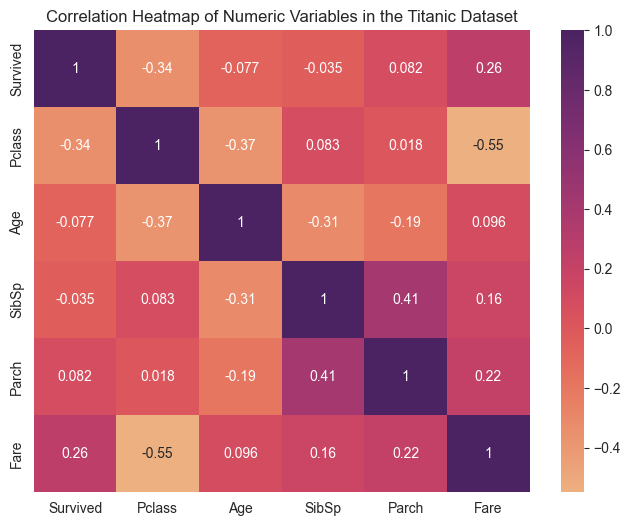

In [21]:
corr_matrix = titanic_data.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='flare')

plt.title("Correlation Heatmap of Numeric Variables in the Titanic Dataset")
plt.show()

**Выводы**

Основные выводы по распределениям целевой переменной и признаков:
 - `Survival`: Большая часть пассажиров не выжила. 
 - `Sex`: Большое количество пассажиров были мужчинами. 
 - `Age`: В среднем, пассажиры были довольно молодыми - в возрасте от (~) 18 до 33 лет. Из интересного, присутствует также достаточно большое количество детей малого возраста и также есть несколько пассажиров пожилого возраста (старше 70 лет). ## are there any outliers?
 - `SibSp` & `Parch`: Чаще всего пассажиры путешествовали без семьи. 
 - `Fare`: Ассиметричное распределение, похожее на биномиальное. Несколько билетов были достаточно дорогими, в среднем не так сильно. ## copute how many outiers?
 - `Embark`: Большинство пассажиров embarked в Southampton. Логично, это была стартовая точка. Кол-во пассажиров уменьшается с каждой последующей остановкой. 
 - `Pclass`: Большинство пассажиров ехали в третьем классе. 

 Основные выводы по влиянию признаков на долю выживших:

 Корреляционная матрица:
 

### Предобработка

**Обработка пропусков**

В данный момент три колонки содержат в себе пропущенные значения: 

- `Age` : 19.86%, 
- `Cabin` : 77.1%, 
- `Embarked` 0.22%

Имеет смысл удалить колонку `Cabin`, так как много значений пропущены и также потому что логически корректно заполнить пропуски будет сложно: `Cabin` является номинальной категориальной переменной - каюты имели разные номера, находились на разных палубах и различались в зависимости от пассажирского класса. 

Пропущенные значения в `Age`, полагаю, что наиболее корректно заполнить медианными значениями, рассчитанными отдельно для групп по полу и пассажирскому классу. Выбран такой подход, так как средний возраст для разных полов и классов отличается. Медиана используется, так как распределения имеют ассиметрию, а среднее является чувствительным к этому. 

В `Embarked`, два пропущенных значения думаю можно заполнить самым встречающимся значением. Это Southampton. 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


X = titanic_data.drop("Survived", axis=1)
y = titanic_data["Survived"]

X = X.drop(columns=["Name", "Ticket", "Cabin"]) ## EXPLAIN


### FEATURE ENGINEERING

numerical_cols = [ 'Age', 'SibSp', 'Parch', 'Fare']
categorical_cols = ['Sex', 'Embarked', 'Pclass']

## I HAVE OUTLIERS
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ('scaler', RobustScaler()) ## EXPLAIN
])

categorical_transformer = Pipeline(steps =[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) ## SHOULD I USE THIS OR LABEL
])

preprocessor = ColumnTransformer(
    transformers= [
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

X_transformed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()

X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names
)

X_transformed_df.head()


### TITLE FEATURE ENGINEERING

##model = RandomForestRegressor()
##
##model_pipeline = Pipeline(steps=[
##    ('preprocessor', preprocessor),
##    ('model', model)
##])




,num__Age,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Pclass_1,cat__Pclass_2,cat__Pclass_3
0,-0.153846,1.0,0.0,-0.312011,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.076923,1.0,0.0,2.461242,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.153846,0.0,0.0,-0.282777,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.846154,1.0,0.0,1.673732,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.846154,0.0,0.0,-0.277363,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [23]:
#age_medians = X.groupby(["Pclass", "Sex"])["Age"].transform("median")
#
#X["Age"] = X["Age"].fillna(age_medians)

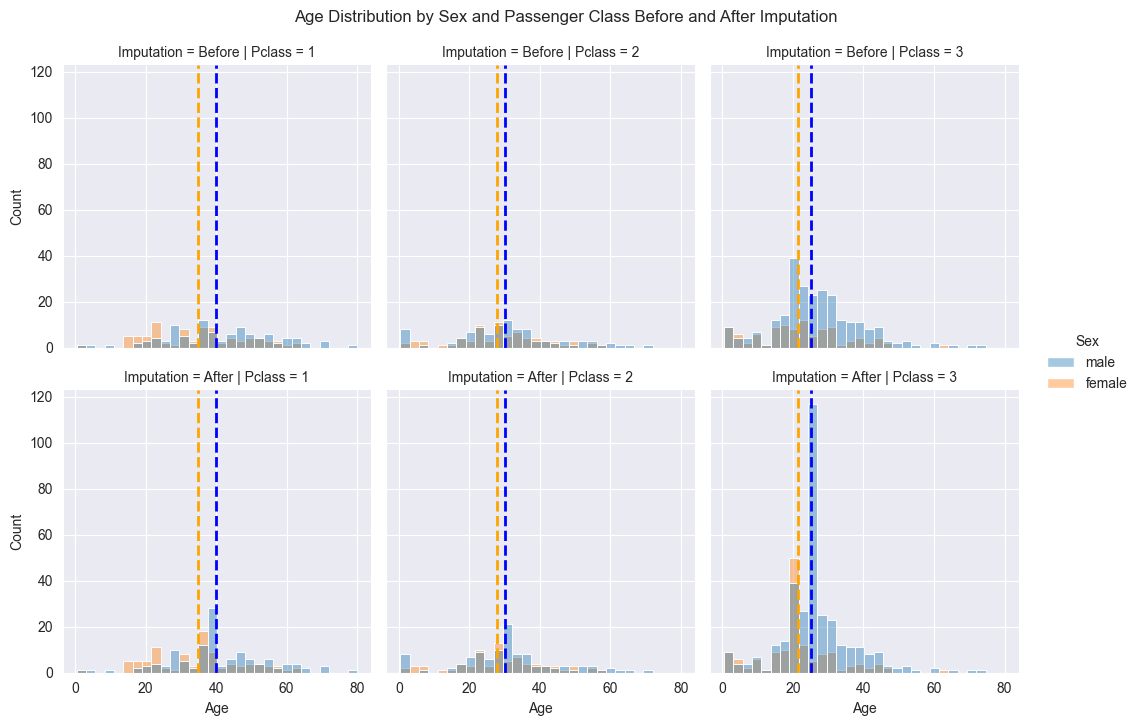

In [ ]:
before_imputation = titanic_data.copy()
before_imputation["Imputation"] = "Before"

after_imputation = titanic_data.copy()

age_medians = after_imputation.groupby(["Pclass", "Sex"])["Age"].transform("median")
after_imputation["Age"] = after_imputation["Age"].fillna(age_medians)

after_imputation["Imputation"] = "After"

age_comparison = pd.concat(
    [before_imputation, after_imputation],
    axis=0,
    ignore_index=True
)

medians = age_comparison.groupby(
    ["Imputation", "Pclass", "Sex"]
)["Age"].median()

colors = {
    "male": "blue",
    "female": "orange"
}

g = sns.displot(
    data=age_comparison,
    x="Age",
    hue="Sex",
    row="Imputation",
    col="Pclass",
    kind="hist",
    bins=30,
    multiple="layer",
    alpha=0.4,
    height=3.5,
    aspect=1
)

for ax in g.axes.flatten():
    title = ax.get_title()
    
    parts = title.split(" | ")
    imputation = parts[0].split(" = ")[1]
    pclass = int(parts[1].split(" = ")[1])
    
    for sex in ["male", "female"]:
        median_age = medians.loc[(imputation, pclass, sex)]
        
        ax.axvline(
            x=median_age,
            color=colors[sex],
            linestyle="--",
            linewidth=2,
            label=f"{sex} median"
        )

g.fig.suptitle(
    "Age Distribution by Sex and Passenger Class Before and After Imputation",
    y=1.03
)

plt.show()

**Кодирование категориальных переменных**

**Масштабирование**

**Feature Engineering**